# Post 2: Supervised Learning
### Seri Pengenalan Machine Learning

---

**Deskripsi**

Notebook ini membahas salah satu paradigma paling penting dalam machine learning: *Supervised Learning*.
Kita akan belajar konsepnya dari nol, melihat contoh nyata, memahami algoritma-algoritma populer,
dan menyentuh dasar-dasar *feature engineering*.

**Yang akan kamu pelajari:**
- Apa itu supervised learning dan perbedaan klasifikasi vs regresi
- Contoh penerapan di kehidupan sehari-hari
- Algoritma klasifikasi populer beserta kapan menggunakannya
- Algoritma regresi populer beserta perbedaan use case-nya
- Pengantar feature engineering

**Prasyarat:** Tidak diperlukan background teknis. Kode Python akan dijelaskan baris per baris.

---


## Setup Awal

Kita mulai dengan mengimpor semua library yang dibutuhkan.

In [1]:
# Library umum untuk manipulasi data
import numpy as np
import pandas as pd

# Library untuk visualisasi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Library machine learning
from sklearn.datasets import load_iris, make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

# Algoritma Klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Algoritma Regresi
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Agar plot lebih rapi
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")


Semua library berhasil diimpor!


---

## 1. Apa Itu Supervised Learning?

### Analogi Sederhana

Bayangkan kamu seorang guru yang mengajari murid mengenali jenis buah.
Kamu menunjukkan ratusan gambar buah **beserta labelnya** (ini apel, ini mangga, ini pisang).
Setelah cukup belajar, murid tersebut bisa menebak jenis buah dari gambar yang belum pernah ia lihat.

Inilah inti dari **supervised learning**: melatih model menggunakan data yang **sudah memiliki jawaban (label)**,
sehingga model dapat memprediksi jawaban untuk data baru.

```
Data Latih (Training Data)
Input (Fitur)         Jawaban (Label)
--------------------  ---------------
[tinggi=170, berat=65]  -> Laki-laki
[tinggi=155, berat=50]  -> Perempuan
[tinggi=180, berat=80]  -> Laki-laki
...
         |
         | Proses Belajar (Training)
         v
       Model
         |
         | Prediksi
         v
Input baru [tinggi=162, berat=55] -> ?
```

### Dua Jenis Tugas dalam Supervised Learning

| Jenis | Pertanyaan yang Dijawab | Output | Contoh |
|-------|------------------------|--------|--------|
| **Klasifikasi** | Termasuk kategori mana? | Label/Kelas | Spam atau bukan spam? |
| **Regresi** | Berapa nilainya? | Angka kontinu | Harga rumah bulan depan? |

### Klasifikasi vs Regresi secara Visual


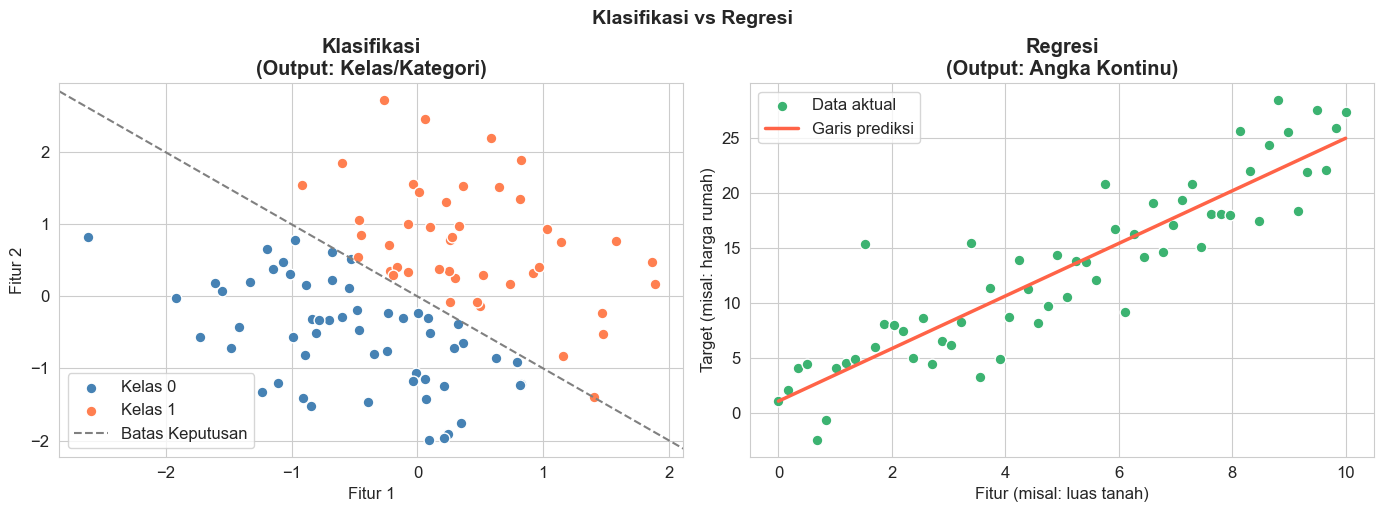

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Klasifikasi ----
np.random.seed(42)
X_cls = np.random.randn(100, 2)
y_cls = (X_cls[:, 0] + X_cls[:, 1] > 0).astype(int)

axes[0].scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1],
                color='steelblue', label='Kelas 0', s=60, edgecolors='white')
axes[0].scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1],
                color='coral', label='Kelas 1', s=60, edgecolors='white')
axes[0].axline((0, 0), slope=-1, color='gray', linestyle='--', linewidth=1.5, label='Batas Keputusan')
axes[0].set_title('Klasifikasi\n(Output: Kelas/Kategori)', fontweight='bold')
axes[0].set_xlabel('Fitur 1')
axes[0].set_ylabel('Fitur 2')
axes[0].legend()

# ---- Regresi ----
X_reg = np.linspace(0, 10, 60)
y_reg = 2.5 * X_reg + np.random.randn(60) * 3

axes[1].scatter(X_reg, y_reg, color='mediumseagreen', s=60,
                edgecolors='white', label='Data aktual')
z = np.polyfit(X_reg, y_reg, 1)
p = np.poly1d(z)
axes[1].plot(X_reg, p(X_reg), color='tomato', linewidth=2.5, label='Garis prediksi')
axes[1].set_title('Regresi\n(Output: Angka Kontinu)', fontweight='bold')
axes[1].set_xlabel('Fitur (misal: luas tanah)')
axes[1].set_ylabel('Target (misal: harga rumah)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Klasifikasi vs Regresi', fontsize=14, fontweight='bold', y=1.02)
plt.show()


---

## 2. Contoh Aplikasi Supervised Learning di Dunia Nyata

Supervised learning bukan sekadar teori. Ia bekerja di balik banyak teknologi yang kita gunakan setiap hari.


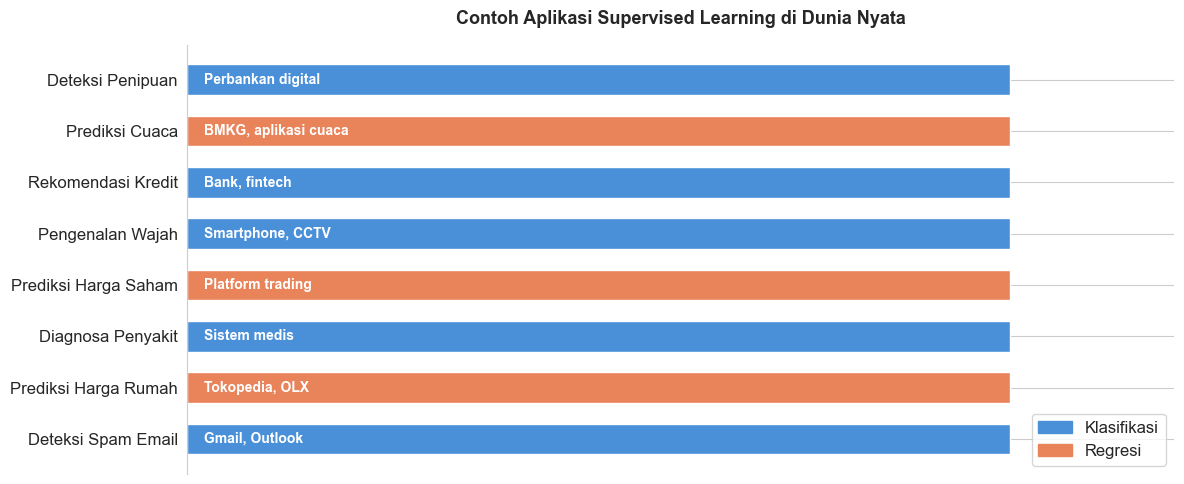

            Aplikasi Jenis Tugas      Contoh Platform
  Deteksi Spam Email Klasifikasi       Gmail, Outlook
Prediksi Harga Rumah     Regresi       Tokopedia, OLX
   Diagnosa Penyakit Klasifikasi         Sistem medis
Prediksi Harga Saham     Regresi     Platform trading
    Pengenalan Wajah Klasifikasi     Smartphone, CCTV
  Rekomendasi Kredit Klasifikasi        Bank, fintech
      Prediksi Cuaca     Regresi BMKG, aplikasi cuaca
    Deteksi Penipuan Klasifikasi    Perbankan digital


In [3]:
# Visualisasi contoh aplikasi supervised learning
aplikasi = {
    "Deteksi Spam Email": ("Klasifikasi", "Gmail, Outlook"),
    "Prediksi Harga Rumah": ("Regresi", "Tokopedia, OLX"),
    "Diagnosa Penyakit": ("Klasifikasi", "Sistem medis"),
    "Prediksi Harga Saham": ("Regresi", "Platform trading"),
    "Pengenalan Wajah": ("Klasifikasi", "Smartphone, CCTV"),
    "Rekomendasi Kredit": ("Klasifikasi", "Bank, fintech"),
    "Prediksi Cuaca": ("Regresi", "BMKG, aplikasi cuaca"),
    "Deteksi Penipuan": ("Klasifikasi", "Perbankan digital"),
}

df_apps = pd.DataFrame(
    [(app, jenis, contoh) for app, (jenis, contoh) in aplikasi.items()],
    columns=["Aplikasi", "Jenis Tugas", "Contoh Platform"]
)

# Warna berdasarkan jenis
colors = df_apps["Jenis Tugas"].map({"Klasifikasi": "#4A90D9", "Regresi": "#E8835A"})

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_apps["Aplikasi"], [1] * len(df_apps),
               color=colors, edgecolor='white', height=0.6)

for i, (_, row) in enumerate(df_apps.iterrows()):
    ax.text(0.02, i, row["Contoh Platform"], va='center',
            fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 1.2)
ax.set_xticks([])
ax.set_title("Contoh Aplikasi Supervised Learning di Dunia Nyata",
             fontsize=13, fontweight='bold', pad=15)

klasifikasi_patch = mpatches.Patch(color='#4A90D9', label='Klasifikasi')
regresi_patch = mpatches.Patch(color='#E8835A', label='Regresi')
ax.legend(handles=[klasifikasi_patch, regresi_patch], loc='lower right')
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

print(df_apps.to_string(index=False))


---

## 3. Algoritma Klasifikasi Populer

Kita akan menggunakan dataset **Iris** yang terkenal: 150 data bunga dengan 4 fitur (panjang dan lebar kelopak),
dikelompokkan ke dalam 3 jenis bunga.

> Bayangkan kamu seorang ahli botani yang ingin membuat alat bantu
> untuk mengidentifikasi jenis bunga berdasarkan ukuran kelopaknya.


In [4]:
# Memuat dataset Iris
iris = load_iris()
X = iris.data          # Fitur: 4 kolom (ukuran kelopak)
y = iris.target        # Label: 0=Setosa, 1=Versicolor, 2=Virginica

# Membagi data: 80% untuk latih, 20% untuk uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi fitur (penting untuk beberapa algoritma)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Total data   : {len(X)} baris")
print(f"Data latih   : {len(X_train)} baris")
print(f"Data uji     : {len(X_test)} baris")
print(f"\nKelas bunga  : {iris.target_names}")
print(f"Fitur        : {iris.feature_names}")
print(f"\nContoh 5 data pertama:")
df_iris = pd.DataFrame(X[:5], columns=iris.feature_names)
df_iris["Jenis Bunga"] = [iris.target_names[i] for i in y[:5]]
print(df_iris.to_string(index=False))


Total data   : 150 baris
Data latih   : 120 baris
Data uji     : 30 baris

Kelas bunga  : ['setosa' 'versicolor' 'virginica']
Fitur        : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Contoh 5 data pertama:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) Jenis Bunga
               5.1               3.5                1.4               0.2      setosa
               4.9               3.0                1.4               0.2      setosa
               4.7               3.2                1.3               0.2      setosa
               4.6               3.1                1.5               0.2      setosa
               5.0               3.6                1.4               0.2      setosa


### 3.1 Logistic Regression

**Intuisi:** Meskipun namanya "regression", algoritma ini digunakan untuk *klasifikasi*.
Bayangkan kita menggambar sebuah garis (atau bidang) yang memisahkan kelas-kelas.
Model menghitung "seberapa yakin" ia bahwa sebuah titik masuk ke suatu kelas,
menggunakan fungsi **sigmoid** yang mengubah nilai apa pun menjadi probabilitas antara 0 dan 1.

**Formula dasar:**

$$P(y=1|x) = \frac{1}{1 + e^{-(w_0 + w_1 x_1 + w_2 x_2 + \ldots)}}$$

Artinya: model menghitung nilai linier dari fitur, lalu "memaksa" nilainya masuk ke rentang 0 hingga 1.
Jika hasilnya > 0.5, prediksinya kelas 1; jika < 0.5, prediksinya kelas 0.

**Cocok untuk:** Data yang bisa dipisahkan oleh garis atau bidang.


In [5]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression - Akurasi: {acc_lr:.2%}")
print("\nLaporan Detail:")
print(classification_report(y_test, y_pred_lr, target_names=iris.target_names))


Logistic Regression - Akurasi: 100.00%

Laporan Detail:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### 3.2 Decision Tree

**Intuisi:** Decision Tree bekerja seperti permainan "20 Questions".
Model belajar serangkaian pertanyaan "ya/tidak" tentang fitur-fitur data,
dan menjawab satu per satu hingga sampai pada sebuah kesimpulan (kelas).

Contoh pertanyaan yang mungkin dipelajari model:
```
Apakah panjang kelopak < 2.5 cm?
    Ya  -> Setosa
    Tidak -> Apakah lebar kelopak < 1.8 cm?
                Ya  -> Versicolor
                Tidak -> Virginica
```

**Kelebihan:** Mudah dipahami dan divisualisasikan.  
**Kelemahan:** Rentan *overfitting* (terlalu hafal data latih).


Decision Tree - Akurasi: 100.00%


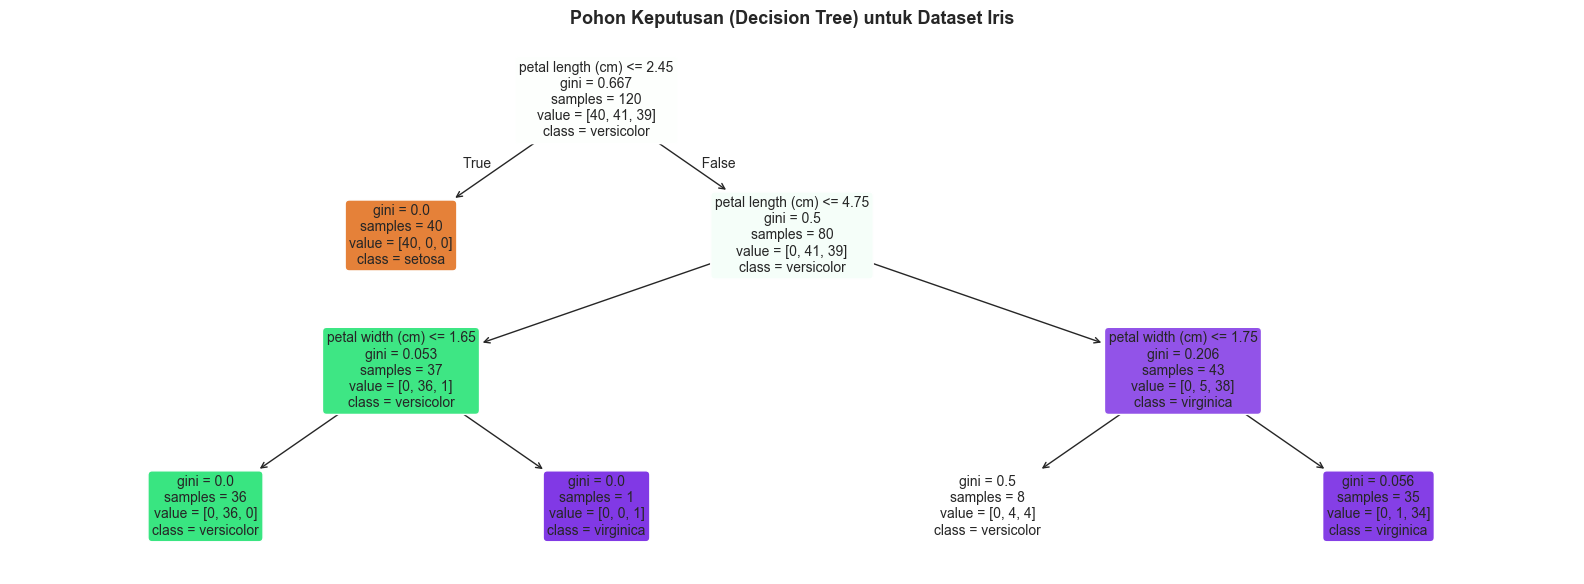

In [6]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)   # Decision Tree tidak perlu scaling

y_pred_dt = dt_model.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree - Akurasi: {acc_dt:.2%}")

# Visualisasi pohon keputusan
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title("Pohon Keputusan (Decision Tree) untuk Dataset Iris",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.3 Random Forest

**Intuisi:** Jika satu pohon keputusan bisa salah, bagaimana jika kita meminta pendapat
dari *ratusan* pohon sekaligus dan mengambil suara terbanyak?

Itulah Random Forest: kumpulan banyak Decision Tree yang masing-masing dilatih
pada *subset acak* dari data. Hasil akhir ditentukan oleh **voting mayoritas**.

```
Input Data
    |
    +---> Pohon 1 -> Versicolor
    +---> Pohon 2 -> Virginica
    +---> Pohon 3 -> Versicolor
    +---> Pohon 4 -> Versicolor
    ...
    +---> Pohon N -> Versicolor
    
    Voting -> Versicolor (pemenang)
```

**Kelebihan:** Lebih akurat dan tahan overfitting dibanding pohon tunggal.


Random Forest - Akurasi: 100.00%


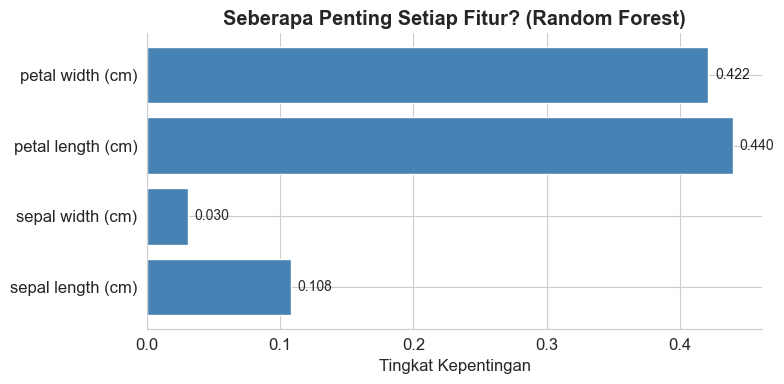


Fitur terpenting: petal length (cm)


In [7]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest - Akurasi: {acc_rf:.2%}")

# Visualisasi Feature Importance
importances = rf_model.feature_importances_
feat_names = iris.feature_names

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(feat_names, importances, color='steelblue', edgecolor='white')
ax.set_xlabel('Tingkat Kepentingan')
ax.set_title('Seberapa Penting Setiap Fitur? (Random Forest)', fontweight='bold')
for bar, val in zip(bars, importances):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print("\nFitur terpenting:", feat_names[np.argmax(importances)])


### 3.4 Support Vector Machine (SVM)

**Intuisi:** SVM mencari **garis pemisah terbaik** antara dua kelas, yaitu garis
yang memiliki jarak (margin) paling besar dari titik-titik data terdekat di setiap kelas.
Titik-titik yang berada tepat di tepi margin inilah yang disebut *support vectors*.

Bayangkan kamu memisahkan kelereng merah dan biru di atas meja menggunakan
sebuah penggaris. SVM mencari posisi penggaris yang memberikan ruang paling lega
di antara kedua kelompok kelereng.

**Formula margin:**

$$\text{Margin} = \frac{2}{||w||}$$

Model berusaha **memaksimalkan margin** ini sambil tetap mengklasifikasikan data dengan benar.

**Kelebihan:** Efektif untuk data berdimensi tinggi.  
**Kelemahan:** Lambat pada dataset yang sangat besar.


SVM (kernel RBF) - Akurasi: 100.00%


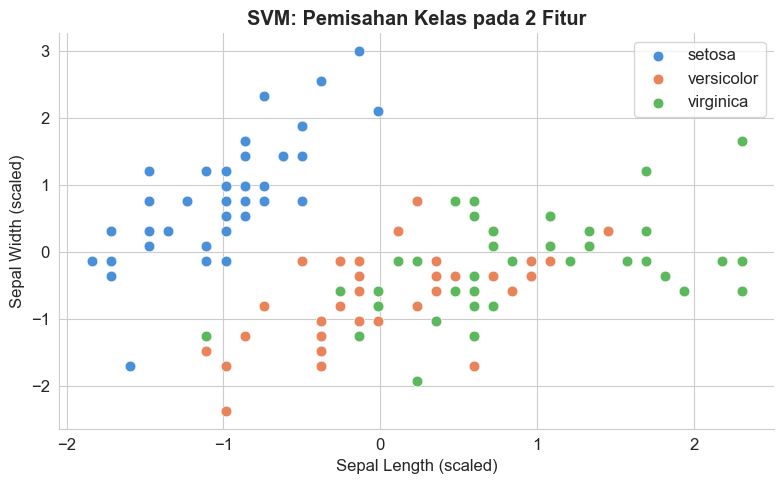

In [8]:
# SVM
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM (kernel RBF) - Akurasi: {acc_svm:.2%}")

# Visualisasi konsep margin pada 2 fitur
fig, ax = plt.subplots(figsize=(8, 5))
X_2d = X_train_scaled[:, :2]
y_2d = y_train

colors_map = {0: '#4A90D9', 1: '#E8835A', 2: '#5CB85C'}
for cls in [0, 1, 2]:
    mask = y_2d == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors_map[cls], label=iris.target_names[cls],
               s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Sepal Length (scaled)')
ax.set_ylabel('Sepal Width (scaled)')
ax.set_title('SVM: Pemisahan Kelas pada 2 Fitur', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 3.5 K-Nearest Neighbors (KNN)

**Intuisi:** "Tunjukkan padaku teman-temanmu, dan aku tahu siapa kamu."

KNN mengklasifikasikan data baru berdasarkan **K tetangga terdekat** di data latih.
Jika K=5, model melihat 5 data latih yang paling mirip dengan data baru,
lalu mengambil kelas yang paling banyak muncul di antara 5 tetangga itu.

```
Data baru: ?

5 Tetangga Terdekat:
  - Setosa
  - Setosa
  - Setosa
  - Versicolor
  - Setosa

Voting: Setosa (4 suara) -> Prediksi = Setosa
```

**Kelebihan:** Sederhana, tidak ada proses "latih" yang kompleks.  
**Kelemahan:** Lambat pada dataset besar karena harus menghitung jarak ke semua data latih.


KNN (K=5) - Akurasi: 100.00%


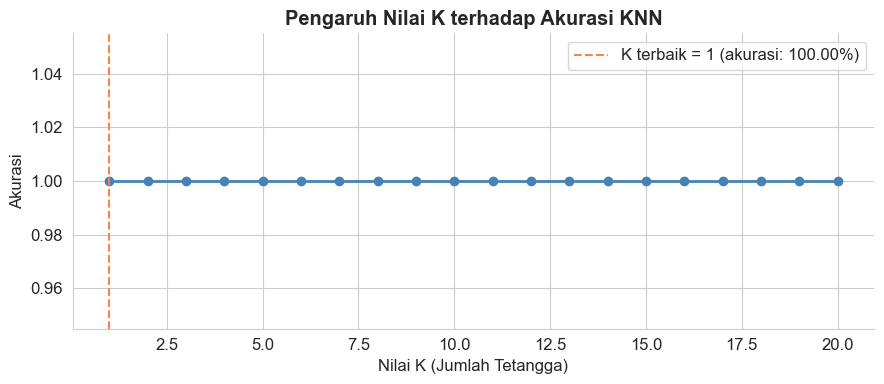

In [9]:
# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN (K=5) - Akurasi: {acc_knn:.2%}")

# Mencari K terbaik
k_values = range(1, 21)
k_scores = []
for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, m.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, k_scores, marker='o', color='steelblue',
        linewidth=2, markersize=6)
best_k = k_values[np.argmax(k_scores)]
ax.axvline(best_k, color='coral', linestyle='--',
           label=f'K terbaik = {best_k} (akurasi: {max(k_scores):.2%})')
ax.set_xlabel('Nilai K (Jumlah Tetangga)')
ax.set_ylabel('Akurasi')
ax.set_title('Pengaruh Nilai K terhadap Akurasi KNN', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 3.6 Perbandingan dan Decision Guide

Sekarang kita rangkum performa semua algoritma klasifikasi yang telah kita coba.


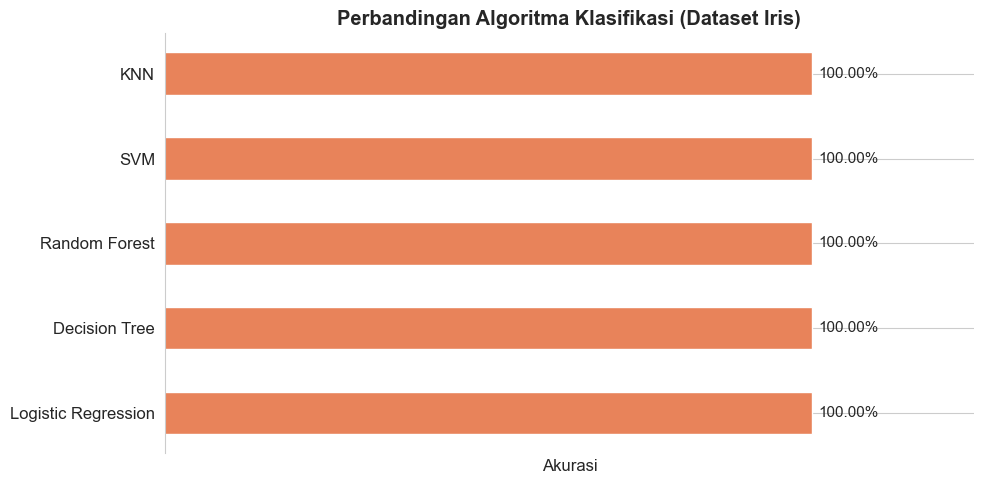

In [10]:
# Ringkasan performa klasifikasi
hasil_klasifikasi = {
    'Logistic Regression': acc_lr,
    'Decision Tree'       : acc_dt,
    'Random Forest'       : acc_rf,
    'SVM'                 : acc_svm,
    'KNN'                 : acc_knn,
}

df_cls = pd.DataFrame(
    list(hasil_klasifikasi.items()),
    columns=['Algoritma', 'Akurasi']
).sort_values('Akurasi', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#4A90D9' if v < max(df_cls['Akurasi']) else '#E8835A'
              for v in df_cls['Akurasi']]
bars = ax.barh(df_cls['Algoritma'], df_cls['Akurasi'],
               color=bar_colors, edgecolor='white', height=0.5)

ax.set_xlim(0.8, 1.05)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2,
            f'{w:.2%}', va='center', fontsize=11)

ax.set_xlabel('Akurasi')
ax.set_title('Perbandingan Algoritma Klasifikasi (Dataset Iris)', fontweight='bold')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xticks([])
plt.tight_layout()
plt.show()


### Kapan Menggunakan Algoritma Mana?

| Kondisi | Algoritma yang Disarankan |
|---------|--------------------------|
| Data bisa dipisahkan secara linier | Logistic Regression |
| Butuh model yang mudah dijelaskan ke non-teknis | Decision Tree |
| Ingin akurasi tinggi, tahan overfitting | Random Forest |
| Data berdimensi tinggi (banyak fitur) | SVM |
| Data kecil, ingin implementasi cepat | KNN |
| Tidak tahu harus mulai dari mana | Random Forest (default terbaik) |

> **Tips Praktis:** Selalu mulai dengan model sederhana (Logistic Regression),
> lalu tingkatkan kompleksitas jika hasilnya belum memuaskan.


---

## 4. Algoritma Regresi Populer

Sekarang kita beralih ke tugas **regresi**: memprediksi nilai numerik.
Kita akan membuat dataset sintetis yang mensimulasikan prediksi harga rumah
berdasarkan satu fitur (misal: luas bangunan dalam meter persegi).


Dataset regresi sintetis:
  Total data    : 120 baris
  Data latih    : 90 baris
  Data uji      : 30 baris
  Fitur         : Luas Bangunan (m2)
  Target        : Harga Rumah (dalam juta rupiah)


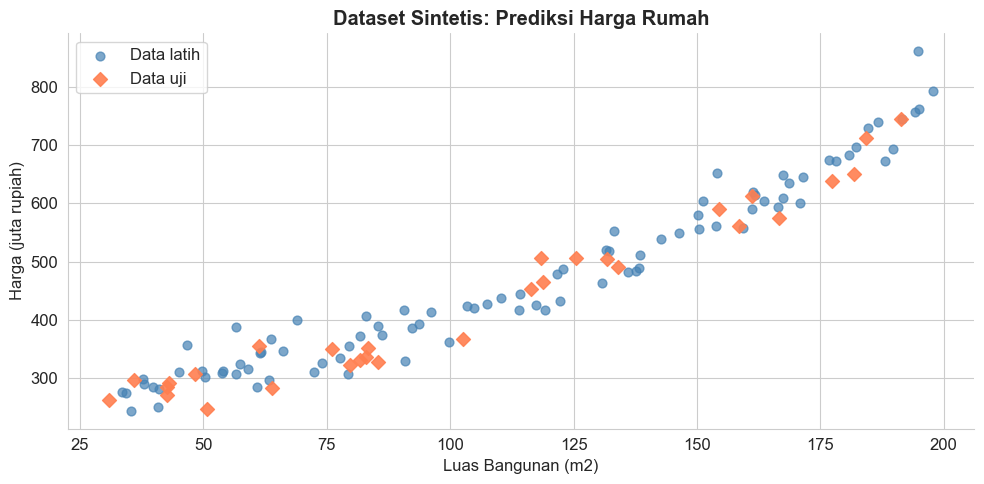

In [11]:
# Membuat dataset regresi sintetis
np.random.seed(42)
n = 120
X_base = np.sort(np.random.uniform(30, 200, n))

# Simulasi harga rumah: ada hubungan non-linier + noise
y_reg = 150 + 2.5 * X_base + 0.012 * (X_base - 100)**2 + np.random.randn(n) * 30

X_reg = X_base.reshape(-1, 1)

# Split data
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

print(f"Dataset regresi sintetis:")
print(f"  Total data    : {n} baris")
print(f"  Data latih    : {len(X_tr)} baris")
print(f"  Data uji      : {len(X_te)} baris")
print(f"  Fitur         : Luas Bangunan (m2)")
print(f"  Target        : Harga Rumah (dalam juta rupiah)")

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_tr, y_tr, color='steelblue', alpha=0.7, label='Data latih', s=40)
ax.scatter(X_te, y_te, color='coral', alpha=0.9, label='Data uji', s=50, marker='D')
ax.set_xlabel('Luas Bangunan (m2)')
ax.set_ylabel('Harga (juta rupiah)')
ax.set_title('Dataset Sintetis: Prediksi Harga Rumah', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 4.1 Linear Regression

**Intuisi:** Linear Regression mencari **garis lurus terbaik** yang melewati data.
Model mempelajari dua nilai: kemiringan (slope) dan titik potong (intercept).

**Formula:**

$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_n x_n$$

Dimana:
- $\hat{y}$ = nilai yang diprediksi
- $w_0$ = intercept (nilai awal saat semua fitur = 0)
- $w_1, w_2, \ldots$ = bobot tiap fitur (seberapa besar pengaruh fitur tersebut)

**Cara model belajar:** Meminimalkan **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Semakin kecil MSE, semakin dekat prediksi ke nilai aslinya.

**Cocok untuk:** Hubungan yang mendekati linier antara fitur dan target.


Linear Regression:
  Persamaan : y = 2.92 * luas + 140.35
  RMSE      : 36.33 juta rupiah
  (rata-rata selisih prediksi vs aktual = 36 juta)


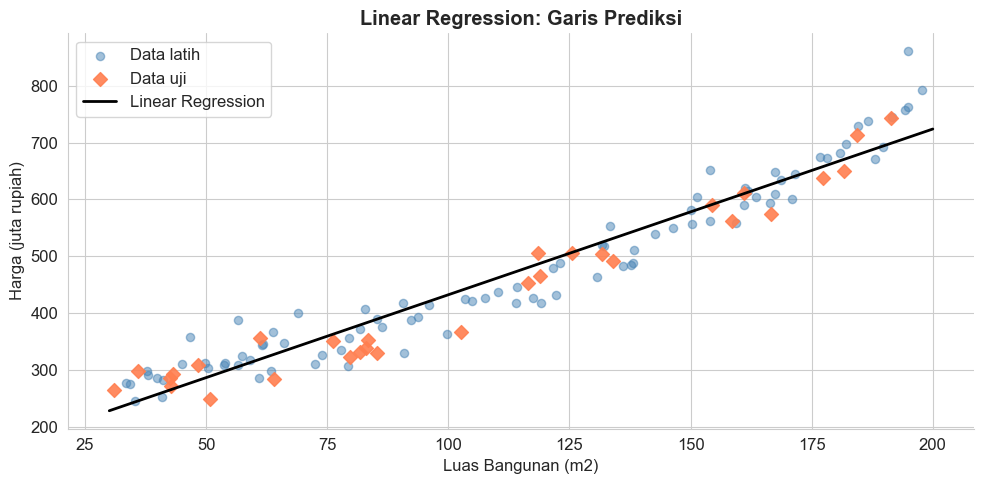

In [12]:
# Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_tr, y_tr)

y_pred_lin = lin_model.predict(X_te)
rmse_lin = np.sqrt(mean_squared_error(y_te, y_pred_lin))

print(f"Linear Regression:")
print(f"  Persamaan : y = {lin_model.coef_[0]:.2f} * luas + {lin_model.intercept_:.2f}")
print(f"  RMSE      : {rmse_lin:.2f} juta rupiah")
print(f"  (rata-rata selisih prediksi vs aktual = {rmse_lin:.0f} juta)")

fig, ax = plt.subplots(figsize=(10, 5))
X_plot = np.linspace(30, 200, 300).reshape(-1, 1)

ax.scatter(X_tr, y_tr, color='steelblue', alpha=0.5, label='Data latih', s=35)
ax.scatter(X_te, y_te, color='coral', alpha=0.9, label='Data uji', s=50, marker='D')
ax.plot(X_plot, lin_model.predict(X_plot), 'k-', linewidth=2, label='Linear Regression')

ax.set_xlabel('Luas Bangunan (m2)')
ax.set_ylabel('Harga (juta rupiah)')
ax.set_title('Linear Regression: Garis Prediksi', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 4.2 Polynomial Regression

**Intuisi:** Bagaimana jika hubungan antara fitur dan target **tidak berbentuk garis lurus**?
Polynomial Regression menambahkan versi "pangkat" dari fitur asli ($x^2, x^3, \ldots$)
sehingga model bisa mempelajari **kurva**.

**Formula (derajat 2):**

$$\hat{y} = w_0 + w_1 x + w_2 x^2$$

Ini masih tergolong *linear model* karena linear terhadap **bobot** ($w$),
meskipun kurva terhadap fitur $x$.

**Perhatian:** Semakin tinggi derajat, kurva semakin "luwes" tapi risiko *overfitting* meningkat.


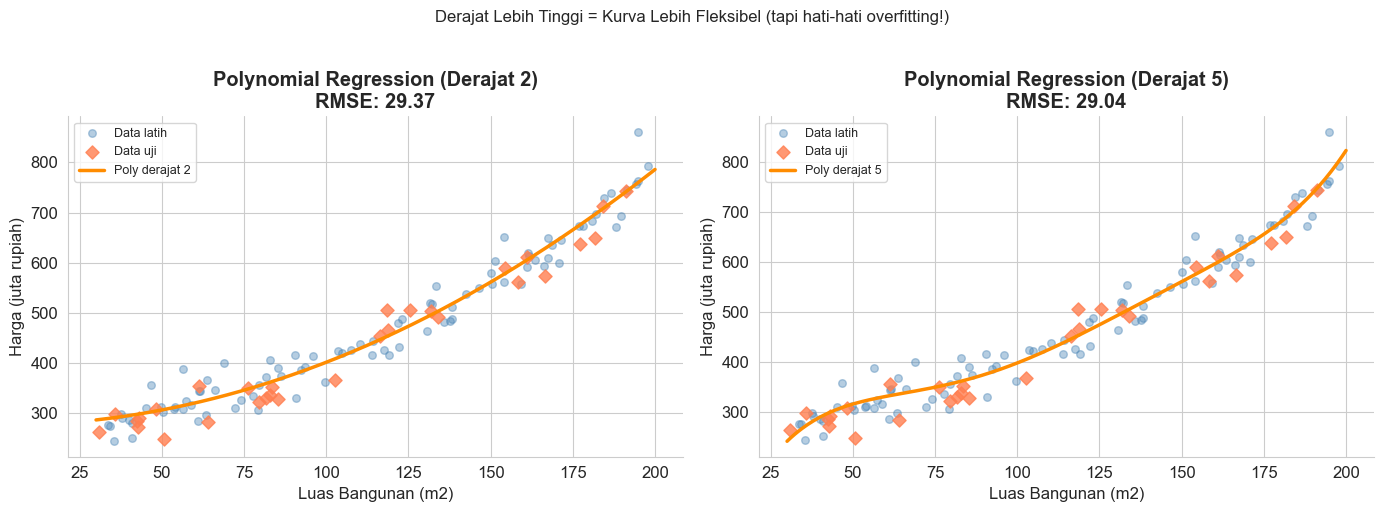

In [13]:
# Polynomial Regression (derajat 2 dan 5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, degree in enumerate([2, 5]):
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('lin', LinearRegression())
    ])
    poly_model.fit(X_tr, y_tr)
    y_pred_poly = poly_model.predict(X_te)
    rmse_poly = np.sqrt(mean_squared_error(y_te, y_pred_poly))

    if degree == 2:
        rmse_poly2 = rmse_poly

    ax = axes[idx]
    ax.scatter(X_tr, y_tr, color='steelblue', alpha=0.4, s=30, label='Data latih')
    ax.scatter(X_te, y_te, color='coral', alpha=0.8, s=45, marker='D', label='Data uji')
    ax.plot(X_plot, poly_model.predict(X_plot),
            color='darkorange', linewidth=2.5, label=f'Poly derajat {degree}')
    ax.set_xlabel('Luas Bangunan (m2)')
    ax.set_ylabel('Harga (juta rupiah)')
    ax.set_title(f'Polynomial Regression (Derajat {degree})\nRMSE: {rmse_poly:.2f}',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Derajat Lebih Tinggi = Kurva Lebih Fleksibel (tapi hati-hati overfitting!)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Ridge dan Lasso Regression

**Masalah yang dipecahkan:** Ketika model terlalu kompleks (banyak fitur atau derajat polynomial tinggi),
ia cenderung "menghafalkan" data latih namun buruk pada data baru. Ini disebut **overfitting**.

**Solusi:** Tambahkan "hukuman" (regularisasi) agar bobot model tidak terlalu besar.

**Ridge Regression (L2):**

$$\text{Loss} = MSE + \lambda \sum_{j} w_j^2$$

Bobot dikecilkan secara proporsional, tapi tidak pernah nol.

**Lasso Regression (L1):**

$$\text{Loss} = MSE + \lambda \sum_{j} |w_j|$$

Bobot bisa dikecilkan hingga **tepat nol**, artinya Lasso bisa otomatis memilih fitur penting.

> $\lambda$ (lambda) adalah parameter yang menentukan seberapa kuat hukuman diterapkan.
> Semakin besar $\lambda$, semakin "hemat" modelnya.


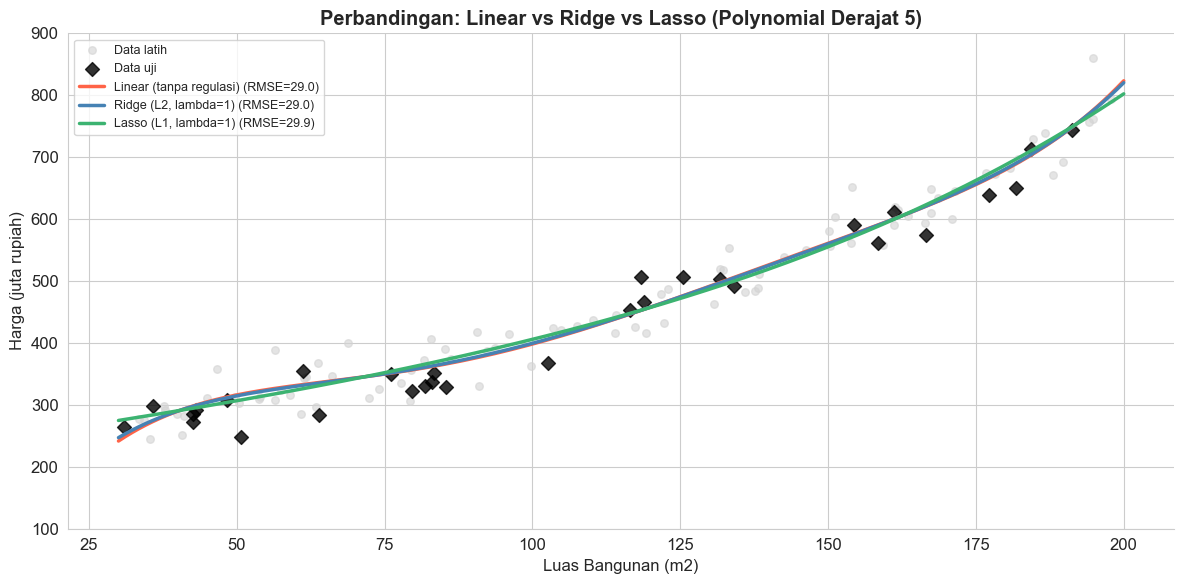

In [14]:
# Perbandingan Linear, Ridge, dan Lasso dengan fitur polynomial
poly_features = PolynomialFeatures(degree=5)
X_tr_poly = poly_features.fit_transform(X_tr)
X_te_poly  = poly_features.transform(X_te)
X_plot_poly = poly_features.transform(X_plot)

models_reg = {
    'Linear (tanpa regulasi)': LinearRegression(),
    'Ridge (L2, lambda=1)' : Ridge(alpha=1.0),
    'Lasso (L1, lambda=1)' : Lasso(alpha=1.0, max_iter=10000),
}

colors_reg = ['tomato', 'steelblue', 'mediumseagreen']
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X_tr, y_tr, color='lightgray', s=30, alpha=0.6, label='Data latih', zorder=1)
ax.scatter(X_te, y_te, color='black', s=50, marker='D', alpha=0.8, label='Data uji', zorder=2)

for (name, model), color in zip(models_reg.items(), colors_reg):
    model.fit(X_tr_poly, y_tr)
    y_pred = model.predict(X_te_poly)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    y_line = model.predict(X_plot_poly)
    ax.plot(X_plot, y_line, linewidth=2.5, color=color, label=f'{name} (RMSE={rmse:.1f})')

ax.set_ylim(100, 900)
ax.set_xlabel('Luas Bangunan (m2)')
ax.set_ylabel('Harga (juta rupiah)')
ax.set_title('Perbandingan: Linear vs Ridge vs Lasso (Polynomial Derajat 5)', fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### Perbedaan Use Case Algoritma Regresi

| Algoritma | Gunakan Saat... | Hindari Saat... |
|-----------|-----------------|-----------------|
| **Linear Regression** | Hubungan fitur-target terlihat linier | Data memiliki pola melengkung yang jelas |
| **Polynomial Regression** | Ada pola kurva yang terlihat di data | Derajat terlalu tinggi (overfitting) |
| **Ridge** | Banyak fitur, semua kemungkinan relevan | Kamu yakin banyak fitur tidak relevan |
| **Lasso** | Ingin seleksi fitur otomatis | Semua fitur penting dan tidak ingin ada yang nol |

> **Aturan umum:** Selalu mulai dengan Linear Regression. Jika akurasi rendah, coba Polynomial.
> Jika terlalu banyak fitur, gunakan Ridge atau Lasso untuk mengontrol kompleksitas.


---

## 5. Feature Engineering: Pengantar

> "Garbage in, garbage out."
> Sebaik apapun algoritma yang kamu gunakan, jika fitur yang masuk berkualitas rendah,
> hasilnya pun akan buruk.

### 5.1 Apa Itu Fitur (Feature)?

**Fitur** adalah informasi mentah yang diberikan ke model untuk membuat prediksi.
Dalam machine learning, setiap kolom pada tabel data (kecuali kolom target) adalah fitur.

Contoh sederhana untuk prediksi harga rumah:

| Fitur (Input) | Target (Output) |
|---------------|-----------------|
| Luas bangunan | |
| Jumlah kamar  | Harga rumah (Rp) |
| Jarak ke pusat kota | |
| Usia bangunan | |


In [15]:
# Membuat contoh dataset rumah sederhana
np.random.seed(0)
n = 200

df_rumah = pd.DataFrame({
    'luas_m2'           : np.random.randint(40, 300, n),
    'jumlah_kamar'      : np.random.randint(1, 6, n),
    'jarak_pusat_km'    : np.round(np.random.uniform(1, 30, n), 1),
    'usia_bangunan_thn' : np.random.randint(0, 40, n),
})

# Harga: dipengaruhi oleh luas, kamar, dan jarak
df_rumah['harga_juta'] = (
    2.0 * df_rumah['luas_m2'] +
    30  * df_rumah['jumlah_kamar'] -
    5   * df_rumah['jarak_pusat_km'] -
    1   * df_rumah['usia_bangunan_thn'] +
    np.random.randn(n) * 50
).round(1)

print("Contoh Dataset Rumah:")
print(df_rumah.head(8).to_string(index=False))
print(f"\nTotal baris  : {len(df_rumah)}")
print(f"Total kolom  : {df_rumah.shape[1]} (4 fitur + 1 target)")


Contoh Dataset Rumah:
 luas_m2  jumlah_kamar  jarak_pusat_km  usia_bangunan_thn  harga_juta
     212             5            14.3                 26       511.3
      87             3             2.3                 30       238.7
     157             5            24.2                  5       359.7
     232             5             3.2                 15       610.9
     291             3            16.0                 37       597.1
     235             4             9.9                 37       573.1
      49             4            17.7                 31       116.9
     251             2            28.8                 32       291.0

Total baris  : 200
Total kolom  : 5 (4 fitur + 1 target)


### 5.2 Mengapa Kualitas Fitur Sangat Penting?

Model machine learning hanya bisa bekerja dengan angka dan pola yang ada dalam fitur.
Jika fitur tidak merepresentasikan masalah dengan baik, model tidak bisa belajar dengan baik.

**Tiga dimensi kualitas fitur:**

1. **Relevansi:** Apakah fitur ini benar-benar berkaitan dengan target?
2. **Kelengkapan:** Seberapa banyak data yang hilang (*missing values*)?
3. **Representasi:** Apakah informasi penting sudah "terlihat" oleh model?

Poin ketiga inilah yang menjadi inti dari *feature engineering*:
**mengubah atau menggabungkan fitur yang ada agar informasi pentingnya lebih mudah ditangkap model**.


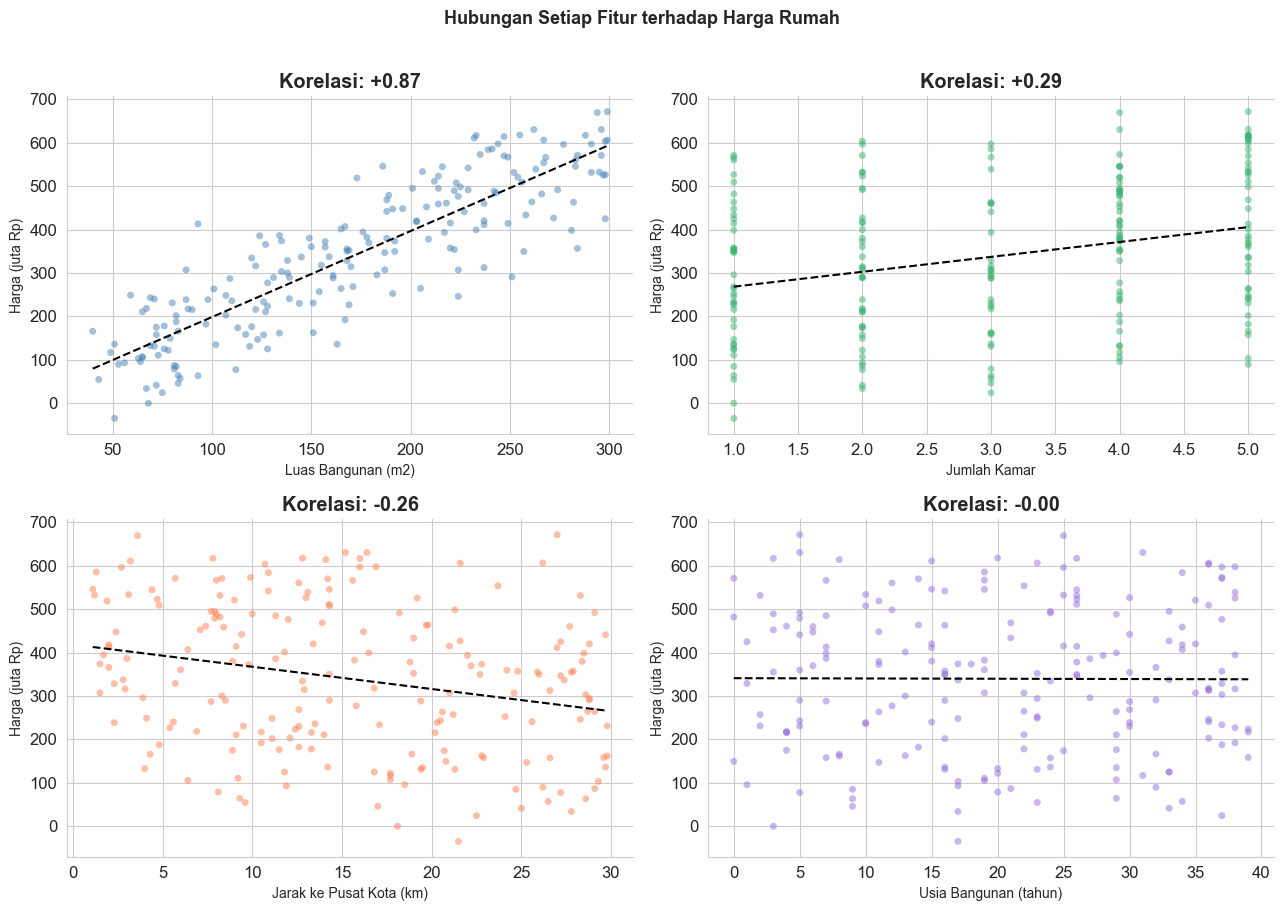

In [16]:
# Visualisasi korelasi fitur terhadap target
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

fitur_plot = ['luas_m2', 'jumlah_kamar', 'jarak_pusat_km', 'usia_bangunan_thn']
label_plot = ['Luas Bangunan (m2)', 'Jumlah Kamar', 'Jarak ke Pusat Kota (km)', 'Usia Bangunan (tahun)']
warna_plot = ['steelblue', 'mediumseagreen', 'coral', 'mediumpurple']

for ax, fitur, label, warna in zip(axes.flat, fitur_plot, label_plot, warna_plot):
    ax.scatter(df_rumah[fitur], df_rumah['harga_juta'],
               color=warna, alpha=0.5, s=25, edgecolors='none')
    z = np.polyfit(df_rumah[fitur], df_rumah['harga_juta'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_rumah[fitur].min(), df_rumah[fitur].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5)
    corr = df_rumah[fitur].corr(df_rumah['harga_juta'])
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Harga (juta Rp)', fontsize=10)
    ax.set_title(f'Korelasi: {corr:+.2f}', fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hubungan Setiap Fitur terhadap Harga Rumah', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.3 Contoh Feature Creation

Mari kita buat fitur-fitur baru dari fitur yang sudah ada.
Ini adalah inti dari *feature engineering*: menciptakan representasi yang lebih informatif.


In [17]:
# Membuat fitur-fitur baru (feature engineering)
df_fe = df_rumah.copy()

# Fitur baru 1: Harga per meter persegi (rasio)
df_fe['harga_per_m2'] = df_fe['harga_juta'] / df_fe['luas_m2']

# Fitur baru 2: Luas rata-rata per kamar
df_fe['luas_per_kamar'] = df_fe['luas_m2'] / df_fe['jumlah_kamar']

# Fitur baru 3: Kategori usia bangunan (binning)
bins  = [0, 5, 15, 30, 100]
labels = ['Baru (0-5th)', 'Modern (6-15th)', 'Tua (16-30th)', 'Sangat Tua (>30th)']
df_fe['kategori_usia'] = pd.cut(df_fe['usia_bangunan_thn'], bins=bins, labels=labels)

# Fitur baru 4: Zona lokasi berdasarkan jarak
df_fe['zona'] = pd.cut(df_fe['jarak_pusat_km'],
                        bins=[0, 5, 15, 100],
                        labels=['Pusat Kota', 'Pinggiran', 'Luar Kota'])

print("Fitur Baru yang Dibuat:")
print("=" * 60)
print(df_fe[['luas_m2', 'jumlah_kamar', 'luas_per_kamar',
             'jarak_pusat_km', 'zona', 'usia_bangunan_thn', 'kategori_usia']].head(8).to_string(index=False))


Fitur Baru yang Dibuat:
 luas_m2  jumlah_kamar  luas_per_kamar  jarak_pusat_km       zona  usia_bangunan_thn      kategori_usia
     212             5           42.40            14.3  Pinggiran                 26      Tua (16-30th)
      87             3           29.00             2.3 Pusat Kota                 30      Tua (16-30th)
     157             5           31.40            24.2  Luar Kota                  5       Baru (0-5th)
     232             5           46.40             3.2 Pusat Kota                 15    Modern (6-15th)
     291             3           97.00            16.0  Luar Kota                 37 Sangat Tua (>30th)
     235             4           58.75             9.9  Pinggiran                 37 Sangat Tua (>30th)
      49             4           12.25            17.7  Luar Kota                 31 Sangat Tua (>30th)
     251             2          125.50            28.8  Luar Kota                 32 Sangat Tua (>30th)


Perbandingan RMSE Model (Linear Regression):
  Sebelum Feature Engineering (4 fitur): RMSE = 54.91 juta rupiah
  Sesudah Feature Engineering (7 fitur): RMSE = 54.95 juta rupiah

Improvement: -0.1% lebih akurat dengan fitur baru!


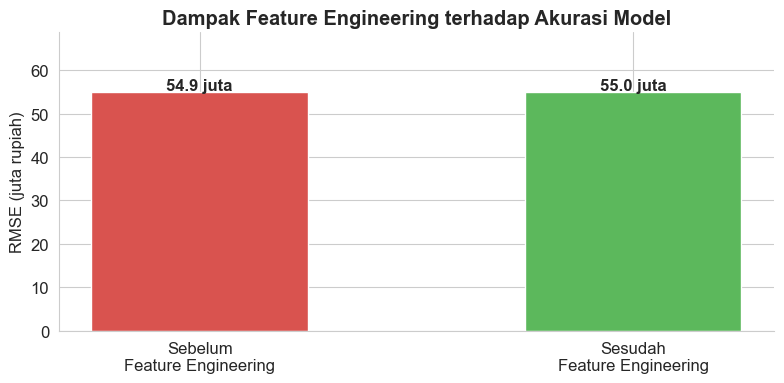

In [18]:
# Membandingkan model sebelum dan sesudah feature engineering
from sklearn.preprocessing import LabelEncoder

# Encode fitur kategorikal
df_enc = df_fe.copy()
for col in ['kategori_usia', 'zona']:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Fitur SEBELUM engineering
fitur_sebelum = ['luas_m2', 'jumlah_kamar', 'jarak_pusat_km', 'usia_bangunan_thn']
# Fitur SESUDAH engineering (tambah fitur baru)
fitur_sesudah = fitur_sebelum + ['luas_per_kamar', 'zona', 'kategori_usia']

X_target = df_enc['harga_juta']

def evaluasi(fitur_list, label):
    X_ = df_enc[fitur_list]
    Xtr, Xte, ytr, yte = train_test_split(X_, X_target, test_size=0.25, random_state=42)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    m = LinearRegression()
    m.fit(Xtr, ytr)
    rmse = np.sqrt(mean_squared_error(yte, m.predict(Xte)))
    print(f"  {label}: RMSE = {rmse:.2f} juta rupiah")
    return rmse

print("Perbandingan RMSE Model (Linear Regression):")
print("=" * 55)
rmse_before = evaluasi(fitur_sebelum, "Sebelum Feature Engineering (4 fitur)")
rmse_after  = evaluasi(fitur_sesudah, "Sesudah Feature Engineering (7 fitur)")
pct = (rmse_before - rmse_after) / rmse_before * 100
print(f"\nImprovement: {pct:.1f}% lebih akurat dengan fitur baru!")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Sebelum\nFeature Engineering', 'Sesudah\nFeature Engineering'],
              [rmse_before, rmse_after],
              color=['#d9534f', '#5cb85c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [rmse_before, rmse_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f} juta', ha='center', fontweight='bold')
ax.set_ylabel('RMSE (juta rupiah)')
ax.set_title('Dampak Feature Engineering terhadap Akurasi Model', fontweight='bold')
ax.set_ylim(0, max(rmse_before, rmse_after) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---

## Rangkuman

Berikut poin-poin utama yang telah kita pelajari dalam notebook ini:

**Supervised Learning**
- Model belajar dari data berlabel untuk memprediksi output pada data baru.
- Dua jenis tugas: *Klasifikasi* (output berupa kelas) dan *Regresi* (output berupa angka).

**Algoritma Klasifikasi**
- **Logistic Regression**: Cepat dan interpretatif, cocok untuk baseline.
- **Decision Tree**: Mudah divisualisasikan dan dipahami.
- **Random Forest**: Ensemble pohon keputusan, akurasi tinggi dan tahan overfitting.
- **SVM**: Efektif untuk data berdimensi tinggi.
- **KNN**: Sederhana, berbasis kesamaan dengan tetangga terdekat.

**Algoritma Regresi**
- **Linear Regression**: Fondasi regresi, cocok untuk hubungan linier.
- **Polynomial Regression**: Menangani kurva non-linier.
- **Ridge/Lasso**: Menambah regularisasi untuk mencegah overfitting.

**Feature Engineering**
- Kualitas fitur sering lebih penting daripada pilihan algoritma.
- Fitur baru bisa dibuat dari fitur yang ada: rasio, binning, gabungan, dll.

---

**Selanjutnya (Post 3):** Evaluasi Model dan Cross-Validation

*Bagaimana kita tahu model kita benar-benar baik dan tidak sekadar hafal data latih?*
